In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
birds_df = pd.read_csv(
    "../cleaned_data/birds_cleaned.csv"
)

birds_df.head()

,AOU_Code,AcceptedTSN,Admin_Sheet,Admin_Unit_Code,Common_Name,Date,Distance,Disturbance,End_Time,Flyover_Observed,Habitat,Humidity,ID_Method,Initial_Three_Min_Cnt,Interval_Length,Location_Type,NPSTaxonCode,Observer,PIF_Watchlist_Status,Plot_Name,Regional_Stewardship_Status,Scientific_Name,Sex,Site_Name,Sky,Start_Time,Temperature,Visit,Wind,Year,Month,Month_Name,Quarter,Season
0,EATO,179276.0,ANTI,ANTI,Eastern Towhee,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Singing,True,0-2.5 min,Forest,83803.0,Elizabeth Oswald,False,ANTI-0036,True,Pipilo erythrophthalmus,Undetermined,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
1,WBNU,178775.0,ANTI,ANTI,White-breasted Nuthatch,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Calling,True,0-2.5 min,Forest,90935.0,Elizabeth Oswald,False,ANTI-0036,False,Sitta carolinensis,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
2,RBWO,178195.0,ANTI,ANTI,Red-bellied Woodpecker,2018-05-22,50 - 100 Meters,No effect on count,06:29:00,False,Forest,79.400002,Calling,False,2.5 - 5 min,Forest,84865.0,Elizabeth Oswald,False,ANTI-0036,False,Melanerpes carolinus,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
3,OROR,179064.0,ANTI,ANTI,Orchard Oriole,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Singing,False,2.5 - 5 min,Forest,93634.0,Elizabeth Oswald,False,ANTI-0036,False,Icterus spurius,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
4,NOMO,178620.0,ANTI,ANTI,Northern Mockingbird,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Visualization,False,2.5 - 5 min,Forest,88394.0,Elizabeth Oswald,False,ANTI-0036,False,Mimus polyglottos,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring


In [3]:
total_species = birds_df["Scientific_Name"].nunique()

print("Total Unique Species:", total_species)

Total Unique Species: 127


In [4]:
top_species = (
    birds_df["Common_Name"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_species.columns = [
    "Species",
    "Observation_Count"
]

top_species

,Species,Observation_Count
0,Northern Cardinal,1125
1,Carolina Wren,993
2,Red-eyed Vireo,738
3,Eastern Tufted Titmouse,720
4,Indigo Bunting,611
5,Eastern Wood-Pewee,574
6,Field Sparrow,492
7,Red-bellied Woodpecker,489
8,American Robin,470
9,Acadian Flycatcher,462


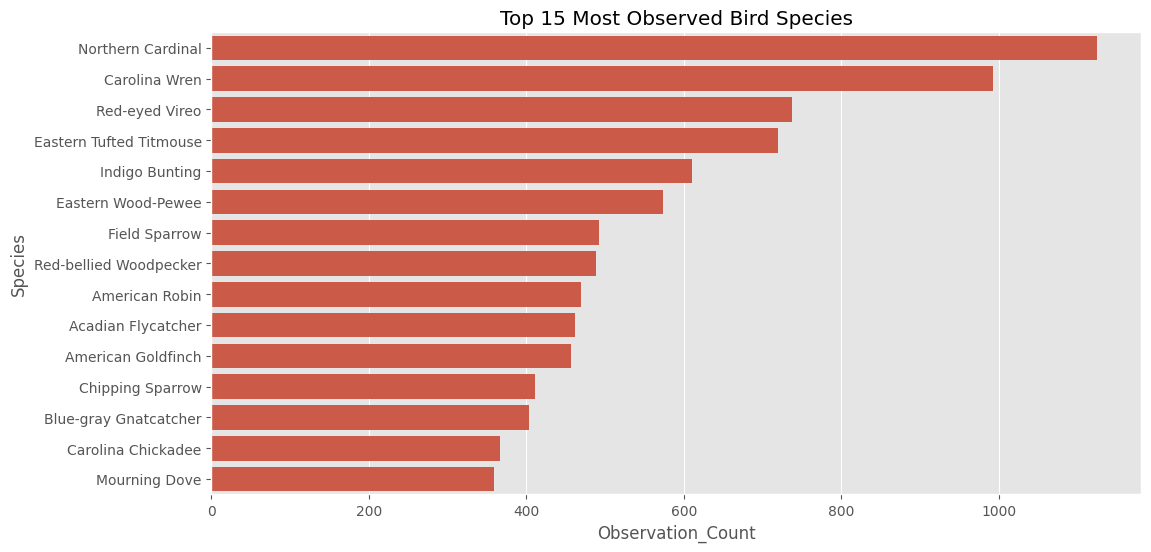

<Figure size 640x480 with 0 Axes>

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_species,
    x="Observation_Count",
    y="Species"
)

plt.title(
    "Top 15 Most Observed Bird Species"
)

plt.show()

plt.savefig(
    "../images/species/top_15_most_observed_species.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [6]:
fig = px.bar(
    top_species,
    x="Observation_Count",
    y="Species",
    orientation="h",
    title="Top 15 Most Observed Species"
)

fig.show()

In [7]:
rare_species = (
    birds_df["Common_Name"]
    .value_counts()
)

rare_species = rare_species[
    rare_species == 1
]

print(
    "Number of Species Observed Only Once:",
    len(rare_species)
)

rare_species.head(20)

Number of Species Observed Only Once: 12


Common_Name
Blue-winged Warbler       1
Peregrine Falcon          1
Nashville Warbler         1
Tennessee Warbler         1
Red-headed Woodpecker     1
Northwestern Crow         1
Savannah Sparrow          1
Chinese Pond-Heron        1
Chestnut-sided Warbler    1
Unidentified Warbler      1
White-throated Sparrow    1
Least Flycatcher          1
Name: count, dtype: int64

In [8]:
species_habitat = (
    birds_df.groupby("Habitat")
    ["Scientific_Name"]
    .nunique()
    .reset_index()
)

species_habitat.columns = [
    "Habitat",
    "Unique_Species"
]

species_habitat

,Habitat,Unique_Species
0,Forest,108
1,Grassland,107


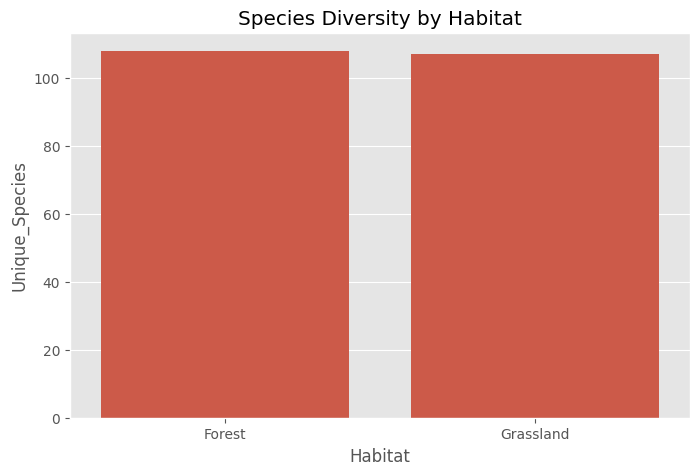

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=species_habitat,
    x="Habitat",
    y="Unique_Species"
)

plt.title(
    "Species Diversity by Habitat"
)

plt.show()

In [10]:
sex_distribution = (
    birds_df["Sex"]
    .value_counts()
    .reset_index()
)

sex_distribution.columns = [
    "Sex",
    "Count"
]

sex_distribution

,Sex,Count
0,Undetermined,6954
1,Unknown,5183
2,Male,3109
3,Female,126


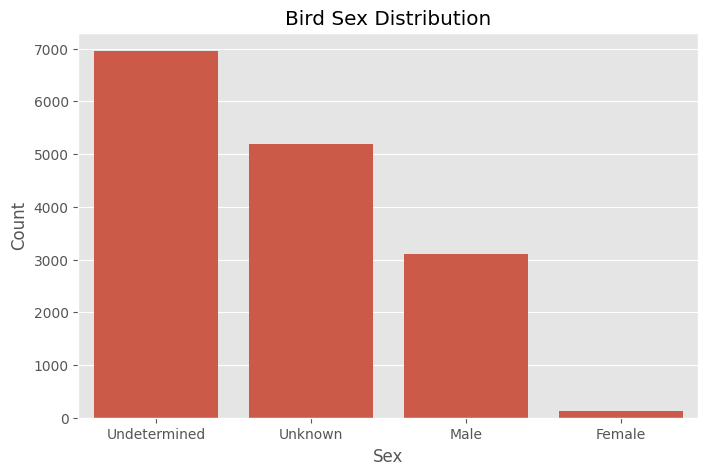

<Figure size 640x480 with 0 Axes>

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sex_distribution,
    x="Sex",
    y="Count"
)

plt.title(
    "Bird Sex Distribution"
)

plt.show()

plt.savefig(
    "../images/species/sex_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [12]:
id_method = (
    birds_df["ID_Method"]
    .value_counts()
    .reset_index()
)

id_method.columns = [
    "Method",
    "Count"
]

id_method

,Method,Count
0,Singing,9621
1,Calling,3941
2,Visualization,1808
3,Unknown,2


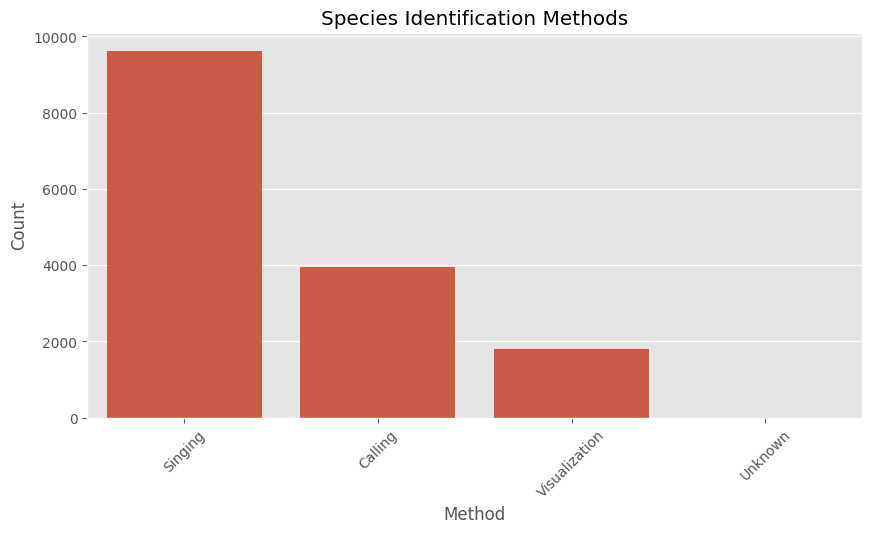

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=id_method,
    x="Method",
    y="Count"
)

plt.title(
    "Species Identification Methods"
)

plt.xticks(rotation=45)

plt.show()

In [14]:
flyover = (
    birds_df["Flyover_Observed"]
    .value_counts()
    .reset_index()
)

flyover.columns = [
    "Flyover",
    "Count"
]

flyover

,Flyover,Count
0,False,14683
1,True,689


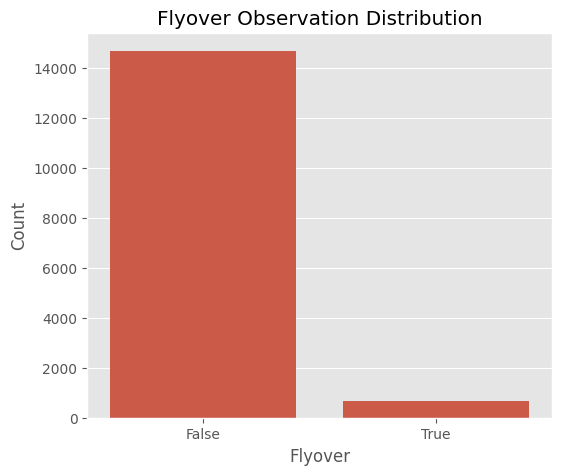

<Figure size 640x480 with 0 Axes>

In [18]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=flyover,
    x="Flyover",
    y="Count"
)

plt.title(
    "Flyover Observation Distribution"
)

plt.show()

plt.savefig(
    "../images/species/flyover_observation_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

## Species Analysis Findings

### 1. Species Diversity
- Total unique bird species observed: 127
- Forest habitat contains 108 unique species.
- Grassland habitat contains 107 unique species.
- Both habitats support nearly identical biodiversity levels.

### 2. Most Frequently Observed Species
Top 5 most observed species:

1. Northern Cardinal (1125 observations)
2. Carolina Wren (993 observations)
3. Red-eyed Vireo (738 observations)
4. Eastern Tufted Titmouse (720 observations)
5. Indigo Bunting (611 observations)

These species appear to be highly adaptable and widespread across monitoring sites.

### 3. Rare Species
- Several species were observed only once.
- These rare sightings may indicate habitat specialization or low population density.

### 4. Sex Distribution
- Undetermined observations dominate the dataset.
- Male birds are observed significantly more often than females.
- Female observations are comparatively rare.

### 5. Identification Method Analysis
- Singing is the most common identification method.
- Calling is the second most common method.
- Visual observations contribute a smaller portion of detections.

This suggests acoustic monitoring is highly effective for bird surveys.

### 6. Flyover Behaviour
- Most observations were non-flyover detections.
- Only a small percentage of birds were recorded while flying overhead.
- Bird activity is primarily associated with habitat occupancy rather than transient movement.

Forest Species Diversity    : 108
Grassland Species Diversity : 107

Difference = 1 species


Although Forest habitats generated more observations,
Grasslands support almost the same species richness.

Therefore conservation resources should not focus only on forests.

Grassland ecosystems contribute nearly equal biodiversity value.